In [1]:
#import relevant libraries: pip install re, pip install natsort, pip install plotly==5.10.0
import sys
import os
import glob

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import datetime as dt8
import math
import matplotlib.pyplot as plt
import decimal
from collections import defaultdict
import re
from natsort import index_natsorted
import dabest
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')

import NLCLIMB 
import NLGRAPHS
import NLMATH

import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 16.22it/s]


Numba compilation complete!


In [42]:
#initial file processing

workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = homecomp

#Comment depending on project type
eopn3work = "Y"
eopn3work = "tgt"

if eopn3work == "Y":
    whomst = "NL"
    filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\2. Processed\\" + whomst + "\\"
    savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\images\\"
    
if eopn3work == "tgt":
    filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\2. Processed\\"
    savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\"
    
    
openPath = specifiedpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR [ATR]"     
driver = "elav"
wt = "w1118"
transgenic = driver + " x " + responder
filename = openPath + transgenic + ".csv"
filenamewt = openPath + wt+"_"+ transgenic + ".csv"

# For compatibility with streamlined variables
expt_file = filename
wt_file = filenamewt
figure_dir = savefiglocation

print(filename)
print(filenamewt)

D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\elav x ACR [ATR].csv
D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\w1118_elav x ACR [ATR].csv


In [43]:

# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

# functions

In [4]:
def falldbest_with_recovery(df, name):
    """Process falls data including Recovery phase using NLMATH pattern."""
    phases = ['Dark', 'Full', 'Recovery']
    combined_data = pd.DataFrame()
    
    for phase in phases:
        phase_df = pd.DataFrame()
        df_phase = df[df['ExperimentState'] == phase]
        filtered_falls = df_phase.filter(regex="Fall.*").sum(axis=0)
        phase_df['Falls'] = filtered_falls
        phase_df['ExperimentState'] = phase
        phase_df = phase_df.reset_index()
        combined_data = pd.concat([combined_data, phase_df], axis=0)
    
    combined_data['Type'] = name
    return combined_data

def velodabest_with_recovery(df, type_name):
    """Process velocity data including Recovery phase using NLMATH pattern."""
    phases = ["Dark", "Full", "Recovery"]
    combined_data = pd.DataFrame()
    
    for phase in phases:
        velocity_processed = NLMATH.calcgraph(df, "Velocity.*")
        phase_data = velocity_processed[velocity_processed['ExperimentState'] == phase]
        
        phase_df = pd.DataFrame()
        phase_df['Velocity'] = phase_data.iloc[:, 2:].mean(axis=0)
        phase_df["ExperimentState"] = phase
        combined_data = pd.concat([combined_data, phase_df])
    
    combined_data["Type"] = type_name
    
    # Remove null values like the original function
    if any(combined_data['Velocity'].isnull()):
        null_indices = combined_data[combined_data['Velocity'].isnull()].index.tolist()
        combined_data = combined_data.drop(index=null_indices)
    
    return combined_data

def separation_with_recovery(df_expt, df_wt, metric):
    """Process metric data across phases including Recovery using original pattern."""
    # Separate data by experimental phase
    expt_phases = {
        'Dark': df_expt[df_expt['ExperimentState'] == 'Dark'],
        'Full': df_expt[df_expt['ExperimentState'] == 'Full'], 
        'Recovery': df_expt[df_expt['ExperimentState'] == 'Recovery']
    }
    
    wt_phases = {
        'Dark': df_wt[df_wt['ExperimentState'] == 'Dark'],
        'Full': df_wt[df_wt['ExperimentState'] == 'Full'],
        'Recovery': df_wt[df_wt['ExperimentState'] == 'Recovery']
    }
    
    filter_pattern = metric + ".*"
    
    # Process experimental data
    expt_results = []
    for phase_name, phase_data in expt_phases.items():
        filtered_data = phase_data.filter(regex=filter_pattern)
        if metric == "Y":
            result = filtered_data.mean(axis=0)
        elif metric == "Fall":
            result = filtered_data.sum(axis=0) / 1
        else:
            result = filtered_data.mean(axis=0)
        expt_results.append((result, phase_name))
    
    # Process wild-type data
    wt_results = []
    for phase_name, phase_data in wt_phases.items():
        filtered_data = phase_data.filter(regex=filter_pattern)
        if metric == "Y":
            result = filtered_data.mean(axis=0)
        elif metric == "Fall":
            result = filtered_data.sum(axis=0) / 1
        else:
            result = filtered_data.mean(axis=0)
        wt_results.append((result, phase_name))
    
    # Build experimental dataframes
    expt_dfs = []
    for result, phase in expt_results:
        phase_df = pd.DataFrame({metric: result, 'ExperimentState': phase})
        expt_dfs.append(phase_df)
    
    expt_combined = pd.concat(expt_dfs).reset_index()
    expt_combined["Type"] = "Expt"
    
    # Build wild-type dataframes
    wt_dfs = []
    for result, phase in wt_results:
        phase_df = pd.DataFrame({metric: result, 'ExperimentState': phase})
        wt_dfs.append(phase_df)
    
    wt_combined = pd.concat(wt_dfs).reset_index()
    wt_combined["Type"] = "WT"
    
    # Combine all data
    final_data = pd.concat([expt_combined, wt_combined])
    return final_data

def totalheight_with_recovery(df_expt, df_wt, driver_name):
    """Prepare height data with Recovery phase using original pattern."""
    height_data = separation_with_recovery(df_expt, df_wt, "Y")
    height_data.loc[height_data['Type'] == 'Expt', 'Type'] = driver_name
    height_data['genre'] = height_data['ExperimentState'] + " " + height_data['Type']
    return height_data

# total to run before graphs

In [44]:
# Load and preprocess data
experimental_data = pd.read_csv(expt_file)
wildtype_data = pd.read_csv(wt_file)

# Remove index columns and apply NLCLIMB processing
processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(experimental_data.drop(experimental_data.columns[[0]], axis=1), driver))
processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wildtype_data.drop(wildtype_data.columns[[0]], axis=1), wt))

# Falls data processing using recovery-compatible functions
expt_falls = falldbest_with_recovery(processed_expt, "Expt")
wt_falls = falldbest_with_recovery(processed_wt, "WT")

falls_data = pd.concat([expt_falls, wt_falls], axis=0).reset_index(drop=True)
falls_data['Type'] = falls_data['Type'].replace("Expt", driver)
falls_data['genre'] = falls_data['ExperimentState'] + " " + falls_data['Type']
falls_data['value'] = 0
falls_data.loc[(falls_data['Falls'] > 0), ['value']] = 1

# Create falls DABEST object
falls_dabest = dabest.load(
    data=falls_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="value", 
    proportional=True, 
    paired="baseline", 
    id_col="index"
)

# Height data processing using recovery-compatible functions
height_data = totalheight_with_recovery(processed_expt, processed_wt, driver)

height_dabest = dabest.load(
    data=height_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="Y", 
    paired="baseline", 
    id_col="index"
)

# Velocity data processing using recovery-compatible functions
expt_velocity = velodabest_with_recovery(processed_expt, "Expt")
wt_velocity = velodabest_with_recovery(processed_wt, "WT")

velocity_data = pd.concat([expt_velocity, wt_velocity]).reset_index(drop=False)
velocity_data.loc[velocity_data['Type'] == 'Expt', 'Type'] = driver
velocity_data['genre'] = velocity_data['ExperimentState'] + " " + velocity_data['Type']

velocity_dabest = dabest.load(
    data=velocity_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="Velocity", 
    paired="baseline", 
    id_col="index"
)

## Graphs

Text(0.5, 0.98, '46416jus x ACR [ATR]')

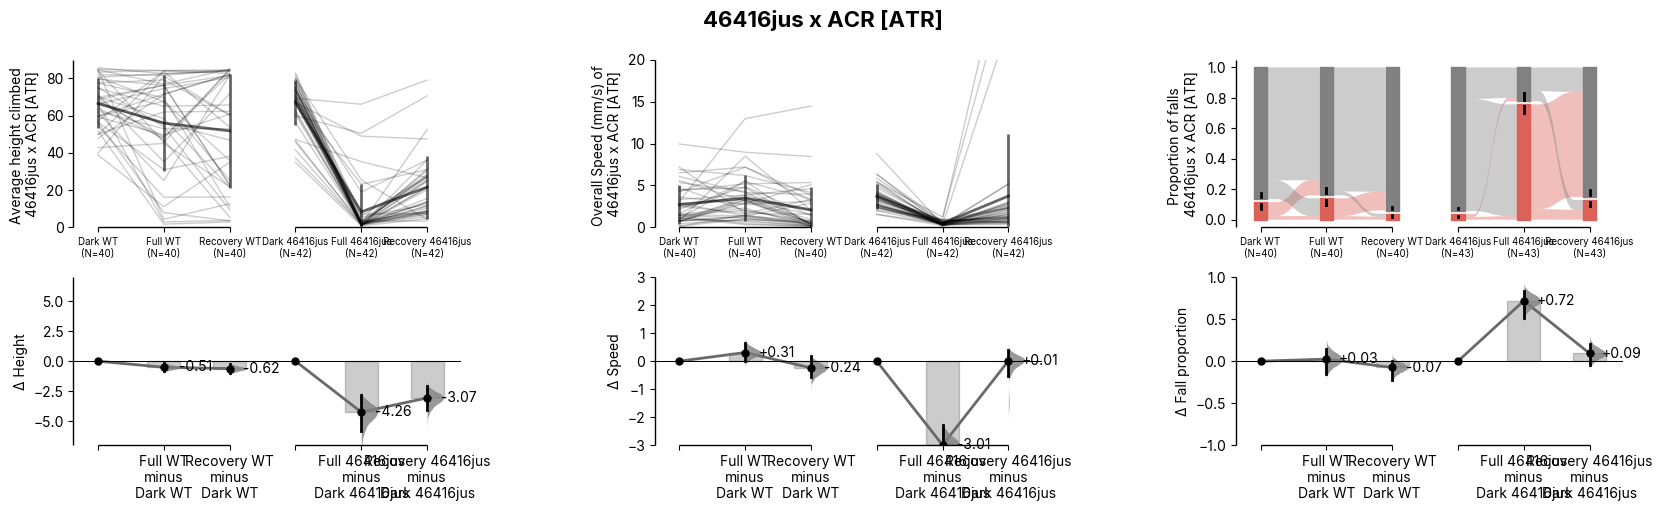

In [312]:
import seaborn as sns

# Format transgenic name for display
display_name = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# Create and configure plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'wspace': 0.5})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Height plot
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name}",
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7),
                            ax=axes[0], **common_style)
#axes[0].legend_.remove()

# Velocity plot  
velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name}",
                              contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3),
                              ax=axes[1], **common_style)
#axes[1].legend_.remove()

# Falls plot
falls_dabest.mean_diff.plot(raw_label=f"Proportion of falls \n{display_name}",
                            contrast_label="Δ Fall proportion", contrast_ylim=(-1, 1),
                            ax=axes[2], **common_style)

# Set title and save
fig.suptitle(display_name, fontsize=16, fontweight='bold')
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")

## Falling only

elav x ACR [ATR]


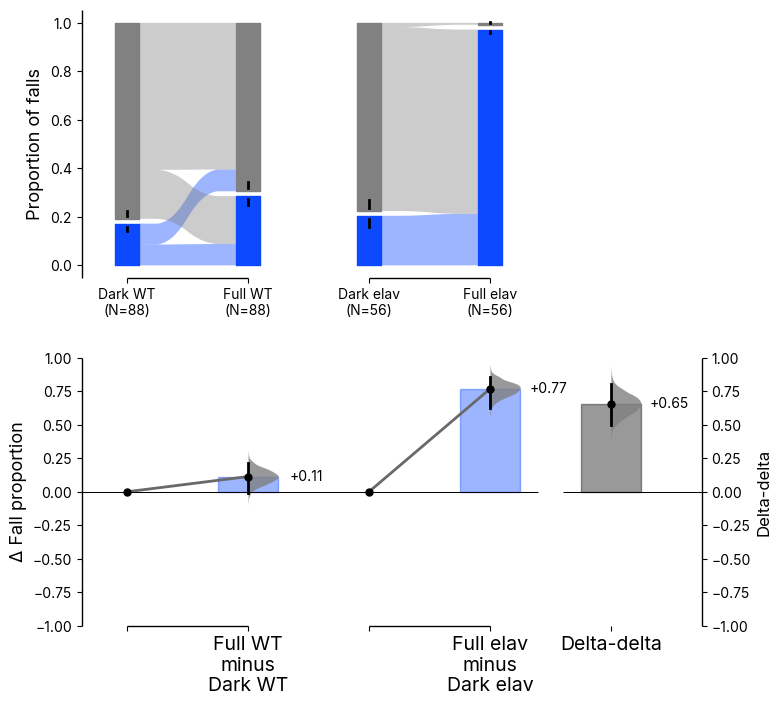

In [55]:
import seaborn as sns

# Format transgenic name for display
display_name = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

figfall, axfall = plt.subplots(figsize=(8, 8))

color_wt = "#000000"
color_trans = "#0A47FF"   #colors are "#B10AFF" for purple and  "#0A47FF" if blue

common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 14,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 5}

falls_dabest_1 = dabest.load(
    data=falls_data[falls_data['ExperimentState'] != "Recovery"], x=["ExperimentState", "Type"], y="value", proportional=True, paired="baseline", delta2 = True, experiment = "Type", 
    experiment_label = ['WT', driver],id_col="index")

falls_dabest_1.mean_diff.plot(raw_label=f"Proportion of falls",
                            contrast_label="Δ Fall proportion", contrast_ylim=(-1, 1), custom_palette=["#808080", color_trans], 
                            contrast_bars_kwargs= {'color': color_trans, 'alpha': 0.4}, ax = axfall,
                             **common_style);


#plt.title(display_name, fontsize=16, fontweight='bold')
print(display_name)
mpl.rcParams['svg.fonttype'] = 'none' 
figfall.savefig(savefiglocation + "fallingspecific_" + date + "_" + transgenic + ".svg")

elav x AsOPN3


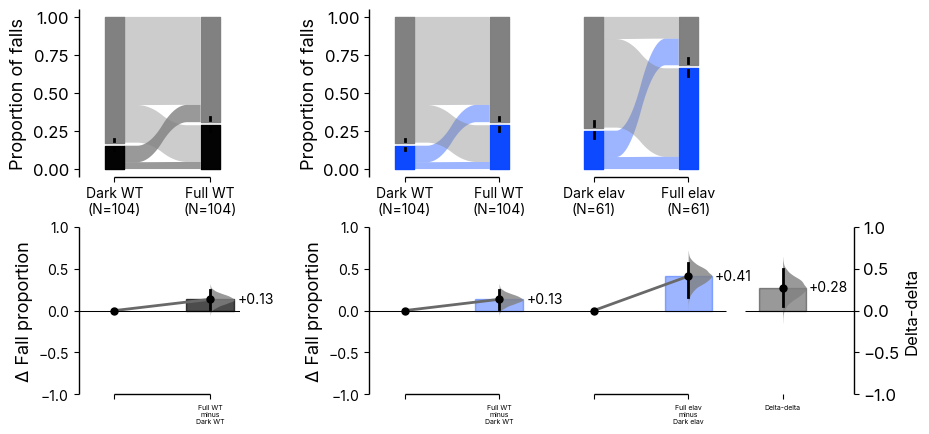

In [304]:
import seaborn as sns

# Format transgenic name for display
display_name = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# Create and configure plots

figfall, axfall = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.4, 'width_ratios': [1,3]})

color_wt = "#000000"
color_trans = "#0A47FF"   #colors are "#B10AFF" for purple and  "#0A47FF" if blue

common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 5,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 5}

falls_dabest_1 = dabest.load(
    data=falls_data[falls_data['ExperimentState'] != "Recovery"], x=["ExperimentState", "Type"], y="value", proportional=True, paired="baseline", delta2 = True, experiment = "Type", 
    experiment_label = ['WT', driver],id_col="index")

falls_dabest_2 = dabest.load( data=falls_data, idx=(("Dark WT", "Full WT")), x="genre",  y="value", proportional=True, paired="baseline", id_col="index")
falls_dabest_2.mean_diff.plot(raw_label=f"Proportion of falls",
                            contrast_label="Δ Fall proportion", contrast_ylim=(-1, 1), custom_palette={0: "#808080", 1: color_wt},ax=axfall[0], 
                            contrast_bars_kwargs= {'color': color_wt, 'alpha': 0.7}, float_contrast=False,
                             **common_style);

falls_dabest_1.mean_diff.plot(raw_label=f"Proportion of falls",
                            contrast_label="Δ Fall proportion", contrast_ylim=(-1, 1), ax=axfall[1],  custom_palette=["#808080", color_trans], 
                            contrast_bars_kwargs= {'color': color_trans, 'alpha': 0.4},
                             **common_style);

for ax in figfall.get_axes():
    ax.tick_params(axis='y', labelsize=12)

#plt.title(display_name, fontsize=16, fontweight='bold')
print(display_name)
mpl.rcParams['svg.fonttype'] = 'none' 
#figfall.savefig(savefiglocation + "fallingspecific_" + date + "_" + transgenic + ".svg")

## forest plot falling

In [56]:
def pergenotypeplotting_meandiff(openPath, files2, k, filesuffixreplacement = None): 
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()
    
    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(filesuffixreplacement, "").replace(" [ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        
        # Create dataframes directly in one step
        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            'meandiff': newfile2read[k+"_meandiff"],
            'Cross': cross,
            'metric': k,
            'samplesize': newfile2read['Sample_size']
        })
        
        singlemeans = pd.DataFrame({
            'mean': samplefile['meandiff'].unique(),
            'cross': cross,
            'samplesize': newfile2read['Sample_size'].unique(),
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })
        

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

In [67]:
def create_table_plot(metricname, singlemeandiff, gridkey1, gridkey2):

    import matplotlib.patches as patches
    
    # Setup
    fig = plt.figure(figsize=(6, 8))
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    
    
    ax_main = plt.subplot2grid((5, 1), (0, 0), rowspan=3)
    ax_table = plt.subplot2grid((5, 1), (3, 0), rowspan=2)
    
    # Extract info
    drivers = [cross.split(' x ')[0] if ' x ' in cross else cross.split(' ')[0] for cross in unique_crosses]
    responders = [cross.split(' x ')[1] if ' x ' in cross else cross.split(' ')[-1] for cross in unique_crosses]
    
    
    violin_color = "#0A47FF"
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], singlemeandiff['mean'], singlemeandiff['err'])):
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        parts = ax_main.violinplot([cross_data], positions=[i], widths=0.6, 
                                 showmeans=False, showmedians=False, showextrema=False)
        
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)
        
        ax_main.errorbar(i, mean, yerr=err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.text(i - 0.1, mean, f'{mean:.2f}', ha='right', va='center', 
                    fontsize=14, color=violin_color, fontweight='bold')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    metric_name = metricname['metric'].unique()[0]
    ax_main.set_ylabel("ΔΔ of " + metric_name, fontsize=18, fontweight='bold')
    ax_main.set_ylim(-0.5, 1)
    ax_main.set_yticks(np.arange(-0.5, 1.1, 0.5)) 
    ax_main.tick_params(axis='y', labelsize=16)
    
    ax_main.set_xlim(-0.5, n_crosses - 1 + 0.5)
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    
    # Create table as a grid of rectangles - NO SPACES between rectangles
    ax_table.set_xlim(-0.5, n_crosses - 1 + 0.75)
    ax_table.set_ylim(0, 1)
    
    # Table structure - rectangles right next to each other
    cell_width = 1.0  # Full width for each cell
    cell_height = 0.2
    cell_start = 0.8
    # Draw table grid with NO gaps between cells
    for i in range(n_crosses):
        # Cell for gridkey1 (top row) - starts at i-0.5
        rect1 = patches.Rectangle((i-0.5, cell_start), cell_width, cell_height, 
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect1)
        
        # Cell for gridkey2 (bottom row) - starts at i-0.5
        rect2 = patches.Rectangle((i-0.5, cell_start-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect2)
        
        rect3 = patches.Rectangle((i-0.5, cell_start-cell_height-cell_height), cell_width, cell_height,
                                linewidth=1, edgecolor='black', facecolor='white')
        ax_table.add_patch(rect3)
        
        
        # Add dots based on responder type
        if gridkey1.lower() in responders[i].lower():
            ax_table.plot(i, cell_start+(cell_height*0.5), 'ko', markersize=12)
        elif gridkey2.lower() in responders[i].lower():
            ax_table.plot(i, (cell_start-cell_height)+(cell_height*0.5), 'ko', markersize=12)
        
        # Add sample size to the 3rd row
        cross = unique_crosses[i]
        sample_size = singlemeandiff[singlemeandiff['cross'] == cross]['samplesize'].iloc[0]
        ax_table.text(i, (cell_start-cell_height-cell_height)+(cell_height*0.5), str(sample_size), 
                     ha='center', va='center', fontsize=11, fontfamily='Inter')
    
    # Add row labels
    ax_table.text(-0.55, cell_start+(cell_height*0.5), gridkey1, ha='right', va='center', fontsize=13)
    ax_table.text(-0.55, (cell_start-cell_height)+(cell_height*0.5), gridkey2, ha='right', va='center', fontsize=13)
    ax_table.text(-0.55, (cell_start-cell_height-cell_height)+(cell_height*0.5), "N's", ha='right', va='center', fontsize=13)
    
    # Add driver labels WITH grouping lines
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    for driver, indices in driver_groups.items():
        # Multiple entries for this driver - draw grouping line
        x_start = min(indices) - 0.4
        x_end = max(indices) + 0.4
        y_pos = (cell_start-cell_height-cell_height) - (cell_height*0.5)
        # Draw horizontal line above driver name
        ax_table.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
        # Center the driver name
        x_center = np.mean(indices)
        ax_table.text(x_center, y_pos-(cell_height*0.25), driver, ha='center', va='top', 
                        fontsize=14, style='italic')
        
    
    # Clean up table axes
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    plt.tight_layout()
    return fig

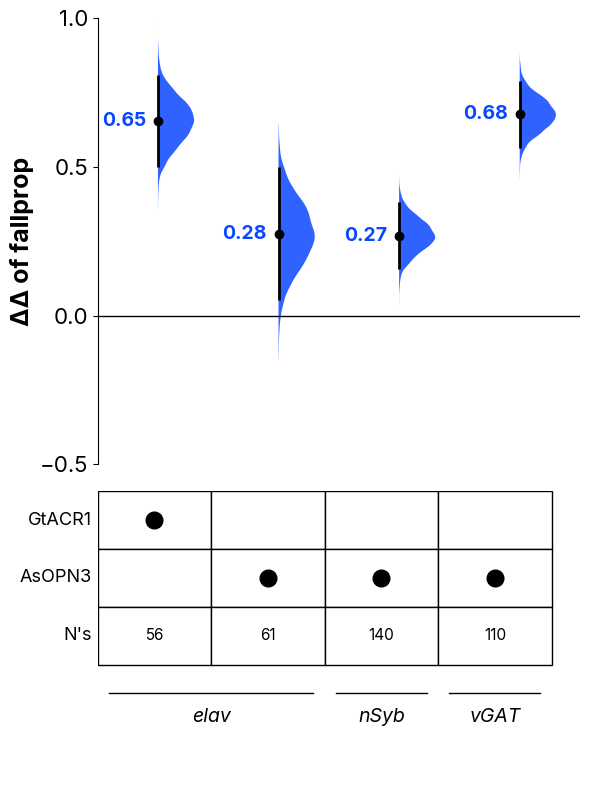

In [69]:
# Example usage of dual responder forest plot
# This example shows how to use the new forestplot_dual_responder function

# Example files for dual responder comparison (GtACR1 vs AsOPN3)
files_dual = [
    f'elav x ACR [ATR] allstats_DARK_FULL_wtcomparison.csv', 
    f'elav x eOPN3 allstats_DARK_FULL_wtcomparison.csv',           
    f'nSyb x eOPN3 allstats_DARK_FULL_wtcomparison.csv',
    f'vGAT x eOPN3 allstats_DARK_FULL_wtcomparison.csv'
    
]

# Generate dual responder forest plot
lstnamings = ['fallprop']

for n in lstnamings:
    # Process data using existing function
    dfmn_dual, dfsmd_dual = pergenotypeplotting_meandiff(
        specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\3. Compiled\\", 
        files_dual, n, filesuffixreplacement=' allstats_DARK_FULL_wtcomparison.csv'
    )
    
    # g_dual = forestplot_dual_responder(dfmn_dual, dfsmd_dual, "AsOPN3", "GtACR1*", " (Dual Responder)")
    g_table = create_table_plot(dfmn_dual.replace("ACR", "GtACR1*", regex = True), dfsmd_dual.replace("ACR", "GtACR1*", regex = True), "GtACR1", "AsOPN3")
    
    mpl.rcParams['svg.fonttype'] = 'none'
    g_table.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot_dual_responder_" + n + ".svg", bbox_inches="tight")
    plt.show()



## Graphs WITHOUT falling

In [45]:
# Load and preprocess data
experimental_data = pd.read_csv(expt_file)
wildtype_data = pd.read_csv(wt_file)

# Remove index columns and apply NLCLIMB processing
processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(experimental_data.drop(experimental_data.columns[[0]], axis=1), driver))
processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wildtype_data.drop(wildtype_data.columns[[0]], axis=1), wt))

# Falls data processing using recovery-compatible functions
expt_falls = falldbest_with_recovery(processed_expt, "Expt")
wt_falls = falldbest_with_recovery(processed_wt, "WT")

falls_data = pd.concat([expt_falls, wt_falls], axis=0).reset_index(drop=True)
falls_data['Type'] = falls_data['Type'].replace("Expt", driver)
falls_data['genre'] = falls_data['ExperimentState'] + " " + falls_data['Type']
falls_data['value'] = 0
falls_data.loc[(falls_data['Falls'] > 0), ['value']] = 1

# Create falls DABEST object
falls_dabest = dabest.load(
    data=falls_data, 
    idx=(("Dark WT", "Full WT"), 
         ("Dark " + driver, "Full " + driver)),
    x="genre", 
    y="value", 
    proportional=True, 
    paired="baseline", 
    id_col="index"
)

# Height data processing using recovery-compatible functions
height_data = totalheight_with_recovery(processed_expt, processed_wt, driver)

height_dabest = dabest.load(
    data=height_data, 
    idx=(("Dark WT", "Full WT"), 
         ("Dark " + driver, "Full " + driver)),
    x="genre", 
    y="Y", 
    paired="baseline", 
    id_col="index"
)

# Velocity data processing using recovery-compatible functions
expt_velocity = velodabest_with_recovery(processed_expt, "Expt")
wt_velocity = velodabest_with_recovery(processed_wt, "WT")

velocity_data = pd.concat([expt_velocity, wt_velocity]).reset_index(drop=False)
velocity_data.loc[velocity_data['Type'] == 'Expt', 'Type'] = driver
velocity_data['genre'] = velocity_data['ExperimentState'] + " " + velocity_data['Type']

velocity_dabest = dabest.load(
    data=velocity_data, 
    idx=(("Dark WT", "Full WT"), 
         ("Dark " + driver, "Full " + driver)),
    x="genre", 
    y="Velocity", 
    paired="baseline", 
    id_col="index"
)

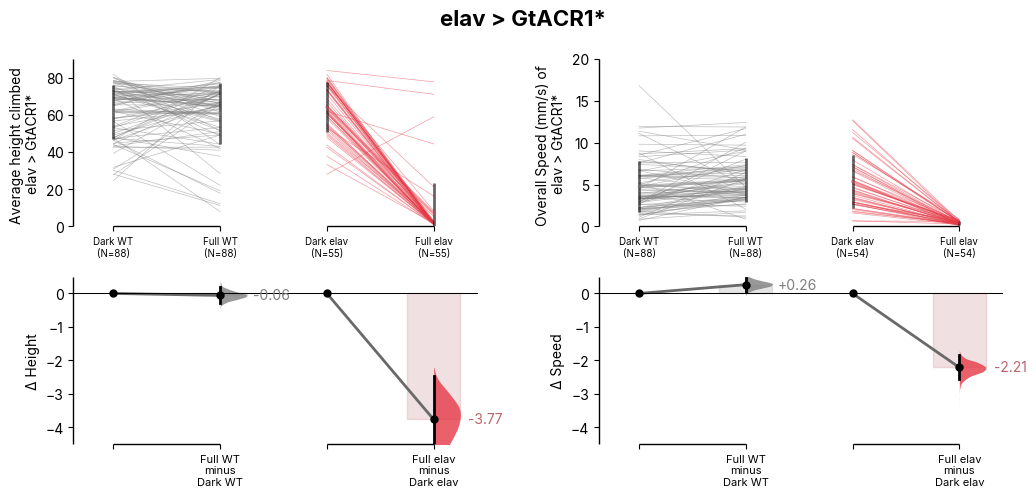

In [ ]:
import seaborn as sns

if "eOPN3" in responder:
    responderrename = responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ")
    
if "[ATR]" in responder:
    responderrename = responder.replace(" [ATR]", "*").replace("ACR", "GtACR1")
                                                                                                                                                                                     
display_name2 = driver + " > " + responderrename

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.3})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 8,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}
firstcolor = '#808080'
secondcolor = "#E63946" #"#0095DA" if blue, #E63946" for purple

color_palette = [firstcolor] * 2 + [secondcolor] * 2

heightdb = height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name2}", 
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-4.5, 0.5),
                            custom_palette=color_palette, 
                            slopegraph_kwargs={'linewidth': 0.5}, 
                            ax=axes2[0], **common_style)
heightdb.axes[1].set_ylabel('Mean Intensity (a.u.)')

for idx, line in enumerate(axes2[0].lines):
    if len(line.get_xdata()) == 2:  
        if idx < len(axes2[0].lines) // 2:  
            line.set_color(firstcolor)
        else:   
            line.set_color(secondcolor)
        line.set_alpha(0.5)

# Velocity plot with colored paired lines
velodb = velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name2}",
                              contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-4.5, 0.5),
                              custom_palette=color_palette,
                              slopegraph_kwargs={'linewidth': 0.5},
                              ax=axes2[1], **common_style)

for idx, line in enumerate(axes2[1].lines):
    if len(line.get_xdata()) == 2:  
        if idx < len(axes2[1].lines) // 2:  
            line.set_color(firstcolor)
        else:  
            line.set_color(secondcolor)
        line.set_alpha(0.5)


# Set title and save
fig2.suptitle(display_name2, fontsize=16, fontweight='bold')
mpl.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['font.family'] = 'Inter'
fig2.savefig(savefiglocation + "twodabestplots_" + date + "_" + transgenic + ".svg")

## LIGHT ON or Recovery only

In [24]:
height_data.genre.unique()

array(['Dark elav', 'Full elav', 'Recovery elav', 'Dark WT', 'Full WT',
       'Recovery WT'], dtype=object)

In [17]:
# Load and preprocess data
experimental_data = pd.read_csv(expt_file)
wildtype_data = pd.read_csv(wt_file)

# Remove index columns and apply NLCLIMB processing
processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(experimental_data.drop(experimental_data.columns[[0]], axis=1), driver))
processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wildtype_data.drop(wildtype_data.columns[[0]], axis=1), wt))

# Height data processing using recovery-compatible functions
height_data = totalheight_with_recovery(processed_expt, processed_wt, driver)

height_dabest = dabest.load(data = height_data,
    x=["ExperimentState", "ExperimentState"], 
    y="Y", experiment = "Type",
    experiment_label= ['WT', driver],
    x1_level = ['Dark', 'Recovery'], paired = "baseline",
    delta2 = True
)

# Velocity data processing using recovery-compatible functions
expt_velocity = velodabest_with_recovery(processed_expt, "Expt")
wt_velocity = velodabest_with_recovery(processed_wt, "WT")

velocity_data = pd.concat([expt_velocity, wt_velocity]).reset_index(drop=False)
velocity_data.loc[velocity_data['Type'] == 'Expt', 'Type'] = driver
velocity_data['genre'] = velocity_data['ExperimentState'] + " " + velocity_data['Type']

velocity_dabest = dabest.load(
    data=velocity_data, 
    x=["ExperimentState", "ExperimentState"], 
    y="Velocity", experiment = "Type",
    experiment_label= ['WT', driver],
    x1_level = ['Dark', 'Recovery'], paired= "baseline",
    delta2 = True
)

IndexError: `id_col` must be specified if `paired` is assigned with a not NoneType value.

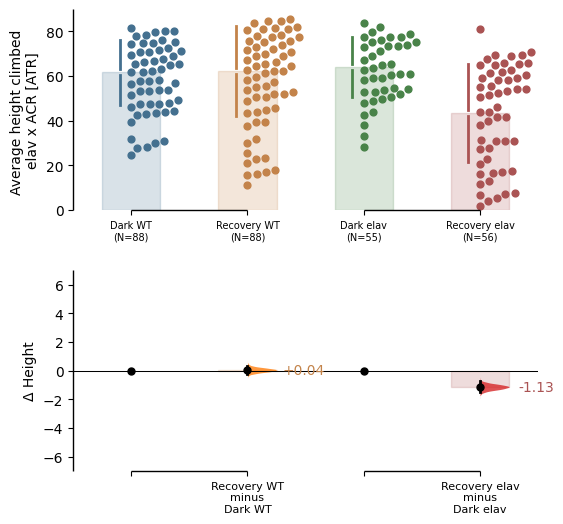

In [ ]:
import seaborn as sns

# Format transgenic name for display
display_name2 = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# # Create and configure plots
# fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.3})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 8,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Height plot
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name2}", 
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7), show_delta2 = True,
                             **common_style);

# Velocity plot  
# velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name2}",
#                               contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3), show_delta2 = True,
#                               ax=axes2[1], **common_style)

# Set title and save
# fig2.suptitle(display_name2, fontsize=16, fontweight='bold')
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")